## 1. Imports

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, joblib
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
BLEU, ROUGE = "#2E86AB", "#D62828"

RAW_PATH   = "/Users/madeleine/Desktop/ml-poc-project/data/raw/natl2018us.csv"
PROC_DIR   = "/Users/madeleine/Desktop/ml-poc-project/data/process"
PLOTS_DIR  = "/Users/madeleine/Desktop/ml-poc-project/plots"
MODELS_DIR = "/Users/madeleine/Desktop/ml-poc-project/models"
for d in [PROC_DIR, PLOTS_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

print("✅ Imports OK")

✅ Imports OK


## 2. Chargement & Nettoyage de la Target

In [25]:
COLONNES = {
    'mager'   : 'Age_Mere',
    'bmi'     : 'IMC_Mere',
    'cig_0'   : 'Tabac_Avant',
    'cig_1'   : 'Tabac_Trim1',
    'cig_3'   : 'Tabac_Trim3',
    'precare' : 'Mois_Debut_Suivi',
    'previs'  : 'Nb_Visites',
    'wic'     : 'Aide_WIC',
    'rf_phype': 'H_Chronique',
    'rf_pdiab': 'D_Chronique',
    'pay'     : 'Assurance',
    'wtgain'  : 'Prise_Poids',
    'dplural'  : 'Pluralite',
    'rf_ppterm': 'ATCD_Premature',
    'rf_artec' : 'PMA',
    'rf_inftr' : 'Traitement_Infertilite',
    'priordead': 'ATCD_Mort_Foetale',
    'rf_ehype' : 'Eclampsie',
    'rf_ghype' : 'HTA_Gestationnelle',
    'rf_gdiab' : 'Diabete_Gestationnel',
    'ab_nicu'  : 'Target'
}

df = pd.read_csv(RAW_PATH, usecols=list(COLONNES.keys()), nrows=100_000)
df = df.rename(columns=COLONNES)
df = df[df['Target'].isin(['Y', 'N'])].copy()
df['Target'] = df['Target'].map({'Y': 1, 'N': 0})

print(f"✅ Chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"   Classe 0 : {(df.Target==0).sum():,}  |  Classe 1 : {(df.Target==1).sum():,}")


✅ Chargé : 99,900 lignes × 21 colonnes
   Classe 0 : 91,001  |  Classe 1 : 8,899


## 3. 🗑️ Suppression de `Nb_Visites`

**Raison 1 — Data Leakage temporel** : le nombre total de visites se construit au fil de la grossesse.
On ne peut pas le connaître en début de suivi → utiliser la valeur finale = regarder dans le futur.

**Raison 2 — Corrélation post-prédictive** : une mère dont le bébé sera admis en NICU accumule
plus de visites *parce que* des complications sont détectées en cours de route. La variable capture
l'effet, pas la cause → inutilisable pour prédire le risque *a priori*.

In [26]:
df = df.drop(columns=['Nb_Visites'])
print(f"✅ Nb_Visites supprimée | Colonnes restantes : {list(df.columns)}")

✅ Nb_Visites supprimée | Colonnes restantes : ['Age_Mere', 'ATCD_Mort_Foetale', 'Mois_Debut_Suivi', 'Aide_WIC', 'Tabac_Avant', 'Tabac_Trim1', 'Tabac_Trim3', 'IMC_Mere', 'Prise_Poids', 'D_Chronique', 'Diabete_Gestationnel', 'H_Chronique', 'HTA_Gestationnelle', 'Eclampsie', 'ATCD_Premature', 'Traitement_Infertilite', 'PMA', 'Assurance', 'Pluralite', 'Target']


## 4. Valeurs Sentinelles CDC → NaN

Le CDC encode les non-réponses avec des codes numériques (`9`, `99`, `99.9`).
**Important** : cette étape est faite AVANT le feature engineering pour que les
nouvelles variables héritent de NaN propres et non de valeurs sentinelles.

In [27]:
SENTINELLES = {
    'IMC_Mere'        : 99.9,
    'Prise_Poids'     : 99,
    'Tabac_Avant'     : 99,
    'Tabac_Trim1'     : 99,
    'Tabac_Trim3'     : 99,
    'Mois_Debut_Suivi': 99,
    'Assurance'       : 9,
    'ATCD_Mort_Foetale': 99,
}

for col, val in SENTINELLES.items():
    df[col] = df[col].replace(val, np.nan)

print("✅ Valeurs sentinelles → NaN")
print()
nan_s = df.isnull().sum()
nan_s = nan_s[nan_s > 0].sort_values(ascending=False)
for col, n in nan_s.items():
    print(f"  {col:<28} {n:>6,}  ({n/len(df)*100:.2f}%)")


✅ Valeurs sentinelles → NaN

  Prise_Poids                   3,598  (3.60%)
  IMC_Mere                      2,216  (2.22%)
  Tabac_Trim3                   1,379  (1.38%)
  Mois_Debut_Suivi                874  (0.87%)
  Tabac_Trim1                     757  (0.76%)
  Tabac_Avant                     742  (0.74%)
  Assurance                       329  (0.33%)
  ATCD_Mort_Foetale               116  (0.12%)


## 5. Feature Engineering

Créé APRÈS le nettoyage des sentinelles pour éviter des valeurs calculées sur des données corrompues.

In [28]:
# Cap outliers Prise_Poids [0–80 lbs] — recommandations IOM
df['Prise_Poids'] = df['Prise_Poids'].where(df['Prise_Poids'].between(0, 80), other=np.nan)

# Evol_Tabac : delta consommation T1 vs avant grossesse
df['Evol_Tabac'] = df['Tabac_Trim1'] - df['Tabac_Avant']

# Suivi_T1 : suivi débuté au 1er trimestre
df['Suivi_T1'] = (df['Mois_Debut_Suivi'] <= 3).astype('Int64')

# Grossesse_Multiple : signal le plus fort (jumeaux 37% NICU, triplets 87%)
df['Grossesse_Multiple'] = (df['Pluralite'] > 1).astype(int)

# ATCD_Mort_Foetale_bin : antécédent binaire (NaN conservés)
df['ATCD_Mort_Foetale_bin'] = (df['ATCD_Mort_Foetale'] > 0).astype('Int64')

print("✅ Feature Engineering terminé")
print(f"   Grossesse_Multiple : {df['Grossesse_Multiple'].value_counts().to_dict()}")
print(f"   ATCD_Mort_Foetale_bin : {df['ATCD_Mort_Foetale_bin'].value_counts(dropna=False).to_dict()}")
print(f"   Shape : {df.shape}")


✅ Feature Engineering terminé
   Grossesse_Multiple : {0: 96469, 1: 3431}
   ATCD_Mort_Foetale_bin : {np.int64(0): 98504, np.int64(1): 1396}
   Shape : (99900, 24)


## 6. Pipeline Encodage & Scaling

In [29]:
X = df.drop(columns=['Target', 'Pluralite', 'ATCD_Mort_Foetale', 'Nb_Visites'])
y = df['Target']

num_features = [
    'Age_Mere', 'Mois_Debut_Suivi', 'Tabac_Avant', 'Tabac_Trim1', 'Tabac_Trim3',
    'IMC_Mere', 'Prise_Poids', 'Evol_Tabac', 'Suivi_T1',
    'Grossesse_Multiple', 'ATCD_Mort_Foetale_bin'
]
cat_features = [
    'Aide_WIC', 'D_Chronique', 'H_Chronique', 'Assurance',
    'ATCD_Premature', 'PMA', 'Traitement_Infertilite',
    'Eclampsie', 'HTA_Gestationnelle', 'Diabete_Gestationnel'
]

print(f"Variables numériques ({len(num_features)}) : {num_features}")
print(f"Variables catégorielles ({len(cat_features)}) : {cat_features}")

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_features),
    ('cat', cat_pipe, cat_features)
])

X_scaled = preprocessor.fit_transform(X)

ohe_cols = (preprocessor
            .named_transformers_['cat']
            .named_steps['ohe']
            .get_feature_names_out(cat_features)
            .tolist())
all_cols = num_features + ohe_cols

print(f"\n✅ Pipeline appliqué → shape : {X_scaled.shape}")
print(f"   OHE colonnes : {ohe_cols}")

joblib.dump(preprocessor, f'{MODELS_DIR}/preprocessor.pkl')
print(f"\n✅ Preprocessor sauvegardé → models/preprocessor.pkl")


KeyError: "['Nb_Visites'] not found in axis"

## 7. Sauvegarde des Datasets

✅ Dataset FULL : 99,900 × 28 colonnes
   Colonnes : ['Age_Mere', 'Mois_Debut_Suivi', 'Tabac_Avant', 'Tabac_Trim1', 'IMC_Mere', 'Prise_Poids', 'Evol_Tabac', 'Suivi_T1', 'Grossesse_Multiple', 'ATCD_Mort_Foetale_bin', 'Aide_WIC_U', 'Aide_WIC_Y', 'D_Chronique_U', 'D_Chronique_Y', 'H_Chronique_U', 'H_Chronique_Y', 'Assurance_2.0', 'Assurance_3.0', 'Assurance_4.0', 'Assurance_5.0', 'Assurance_6.0', 'Assurance_8.0', 'ATCD_Premature_U', 'ATCD_Premature_Y', 'PMA_U', 'PMA_X', 'PMA_Y']
   → /Users/madeleine/Desktop/ml-poc-project/data/process/processed_data_full.csv

✅ Dataset PCA  : 99,900 × 5 colonnes (4 composantes → 95% variance)
   → /Users/madeleine/Desktop/ml-poc-project/data/process/processed_data_pca.csv


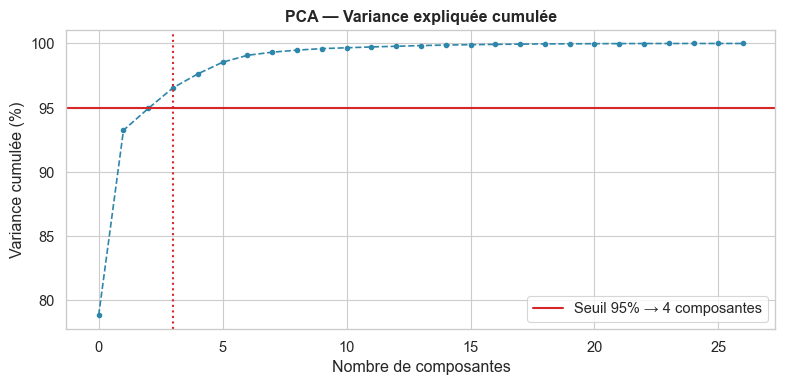


  RÉSUMÉ FINAL
  processed_data_full.csv → 27 features réelles
  processed_data_pca.csv  → 4 composantes PCA
  preprocessor.pkl        → pipeline sauvegardé


In [ ]:
# ── Dataset FULL (pour Random Forest & HistGradientBoosting) ─────────────────
df_full = pd.DataFrame(X_scaled, columns=all_cols)
df_full['Target_Risk'] = y.values
path_full = f"{PROC_DIR}/processed_data_full.csv"
df_full.to_csv(path_full, index=False)
print(f"✅ Dataset FULL : {df_full.shape[0]:,} × {df_full.shape[1]} colonnes")
print(f"   Colonnes : {all_cols}")
print(f"   → {path_full}")

# ── Dataset PCA (archivage) ───────────────────────────────────────────────────
pca_explore = PCA()
pca_explore.fit(X_scaled)
n_comp = int(np.argmax(np.cumsum(pca_explore.explained_variance_ratio_) >= 0.95) + 1)

pca_final = PCA(n_components=n_comp)
X_pca = pca_final.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_comp)])
df_pca['Target_Risk'] = y.values
path_pca = f"{PROC_DIR}/processed_data_pca.csv"
df_pca.to_csv(path_pca, index=False)
print(f"\n✅ Dataset PCA  : {df_pca.shape[0]:,} × {df_pca.shape[1]} colonnes ({n_comp} composantes → 95% variance)")
print(f"   → {path_pca}")

# Graphique PCA
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.cumsum(pca_explore.explained_variance_ratio_)*100,
        marker='o', markersize=3, linestyle='--', color=BLEU)
ax.axhline(95, color=ROUGE, linestyle='-', linewidth=1.5,
           label=f'Seuil 95% → {n_comp} composantes')
ax.axvline(n_comp-1, color=ROUGE, linestyle=':', linewidth=1.5)
ax.set_xlabel('Nombre de composantes'); ax.set_ylabel('Variance cumulée (%)')
ax.set_title('PCA — Variance expliquée cumulée', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/preprocessing_pca_variance.png", dpi=300)
plt.show(); plt.close()

print(f"\n{'='*55}")
print(f"  RÉSUMÉ FINAL")
print(f"{'='*55}")
print(f"  processed_data_full.csv → {len(all_cols)} features réelles")
print(f"  processed_data_pca.csv  → {n_comp} composantes PCA")
print(f"  preprocessor.pkl        → pipeline sauvegardé")
print(f"{'='*55}")